# Deep Learning — Scoring Credit Ivoirien
**Objectif :** Construire un reseau de neurones avec TensorFlow/Keras
pour predire le risque de defaut de paiement.

In [11]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")

TensorFlow version : 2.21.0
Keras version      : 3.15.1


In [12]:
# Charger les donnees sauvegardees
PATH = r'C:\Users\emman\Documents\Portfolio\credit-scoring-deep-learning\data\\'

X_train = np.load(PATH + 'X_train.npy')
X_test  = np.load(PATH + 'X_test.npy')
y_train = np.load(PATH + 'y_train.npy')
y_test  = np.load(PATH + 'y_test.npy')

with open(PATH + 'features.json', 'r') as f:
    features = json.load(f)

print(f"Donnees chargees !")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Features : {len(features)}")

Donnees chargees !
X_train : (119999, 14)
X_test  : (30000, 14)
y_train : (119999,)
y_test  : (30000,)
Features : 14


In [13]:
# Calculer le poids des classes
# pour gerer le desequilibre (6.68% de defauts)
total    = len(y_train)
n_normal = (y_train == 0).sum()
n_defaut = (y_train == 1).sum()

# Poids inverse de la frequence
poids_normal = total / (2 * n_normal)
poids_defaut = total / (2 * n_defaut)

class_weights = {
    0: poids_normal,
    1: poids_defaut
}

print(f"Gestion du desequilibre :")
print(f"  Clients normaux : {n_normal:,} ({n_normal/total*100:.2f}%)")
print(f"  Clients defaut  : {n_defaut:,} ({n_defaut/total*100:.2f}%)")
print(f"\nPoids des classes :")
print(f"  Normal : {poids_normal:.4f}")
print(f"  Defaut : {poids_defaut:.4f}")

Gestion du desequilibre :
  Clients normaux : 111,978 (93.32%)
  Clients defaut  : 8,021 (6.68%)

Poids des classes :
  Normal : 0.5358
  Defaut : 7.4803


In [14]:
# Construction du reseau de neurones
def construire_modele(input_dim):
    modele = keras.Sequential([

        # Couche d'entree
        layers.Input(shape=(input_dim,)),

        # Couche cachee 1
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Couche cachee 2
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Couche cachee 3
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Couche de sortie
        layers.Dense(1, activation='sigmoid')
    ])

    modele.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

    return modele

# Creer le modele
modele = construire_modele(input_dim=X_train.shape[1])

# Afficher l'architecture
modele.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# Callbacks — outils pour controler l'entrainement
callbacks = [

    # Arreter si pas d'amelioration apres 10 epochs
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),

    # Sauvegarder le meilleur modele
    keras.callbacks.ModelCheckpoint(
        filepath=r'C:\Users\emman\Documents\Portfolio\credit-scoring-deep-learning\models\best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Reduire le learning rate si stagnation
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=5,
        mode='max',
        verbose=1
    )
]

print("Callbacks configures !")
print("  EarlyStopping    → arret si pas d'amelioration")
print("  ModelCheckpoint  → sauvegarde du meilleur modele")
print("  ReduceLROnPlateau → reduction du learning rate")

Callbacks configures !
  EarlyStopping    → arret si pas d'amelioration
  ModelCheckpoint  → sauvegarde du meilleur modele
  ReduceLROnPlateau → reduction du learning rate


In [16]:
# Entrainement du reseau de neurones
print("Entrainement en cours...")
print("(Cela peut prendre 5-10 minutes)\n")

historique = modele.fit(
    X_train, y_train,
    epochs=100,
    batch_size=512,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\nEntrainement termine !")

Entrainement en cours...
(Cela peut prendre 5-10 minutes)

Epoch 1/100
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7192 - auc: 0.7870 - loss: 0.5808 - precision: 0.1553 - recall: 0.7212
Epoch 1: val_auc improved from None to 0.85015, saving model to C:\Users\emman\Documents\Portfolio\credit-scoring-deep-learning\models\best_model.keras

Epoch 1: finished saving model to C:\Users\emman\Documents\Portfolio\credit-scoring-deep-learning\models\best_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.7192 - auc: 0.7871 - loss: 0.5807 - precision: 0.1554 - recall: 0.7214 - val_accuracy: 0.8291 - val_auc: 0.8502 - val_loss: 0.4414 - val_precision: 0.2334 - val_recall: 0.6813 - learning_rate: 0.0010
Epoch 2/100
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7613 - auc: 0.8285 - loss: 0.5191 - precision: 0.1837 - recall: 0.7455
Epoch 2: val_auc improved from 0.85015 to 0.85611, saving model to C:\Users\emman\Documents\Portfolio\credit-scoring-deep-learning\

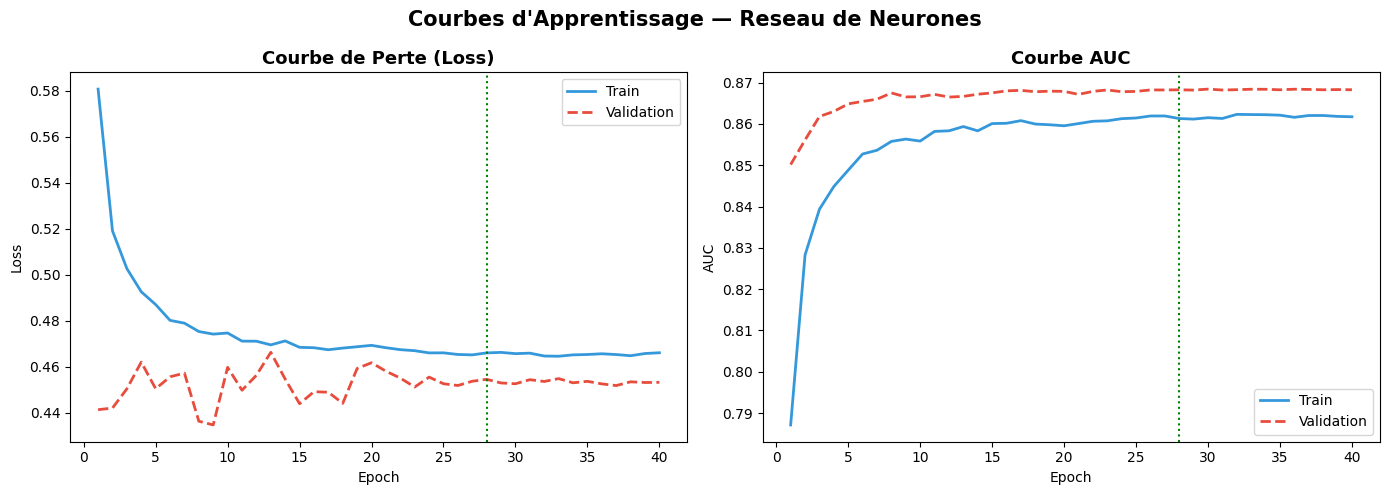

Graphique sauvegarde !


In [17]:
# Visualisation des courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(historique.history['loss']) + 1)

# Courbe de perte
axes[0].plot(
    epochs, historique.history['loss'],
    color='#3498db', linewidth=2, label='Train'
)
axes[0].plot(
    epochs, historique.history['val_loss'],
    color='#e74c3c', linewidth=2,
    linestyle='--', label='Validation'
)
axes[0].set_title(
    'Courbe de Perte (Loss)',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].axvline(
    x=28, color='green',
    linestyle=':', linewidth=1.5,
    label='Meilleur modele (epoch 28)'
)

# Courbe AUC
axes[1].plot(
    epochs, historique.history['auc'],
    color='#3498db', linewidth=2, label='Train'
)
axes[1].plot(
    epochs, historique.history['val_auc'],
    color='#e74c3c', linewidth=2,
    linestyle='--', label='Validation'
)
axes[1].set_title(
    'Courbe AUC',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].axvline(
    x=28, color='green',
    linestyle=':', linewidth=1.5,
    label='Meilleur modele (epoch 28)'
)

plt.suptitle(
    'Courbes d\'Apprentissage — Reseau de Neurones',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../reports/06_courbes_apprentissage.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")

Evaluation du meilleur modele...
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step

Resultats du Reseau de Neurones :
AUC-ROC : 0.8684

Rapport de classification :
              precision    recall  f1-score   support

   Rembourse       0.98      0.79      0.88     27995
      Defaut       0.21      0.79      0.33      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.79      0.60     30000
weighted avg       0.93      0.79      0.84     30000



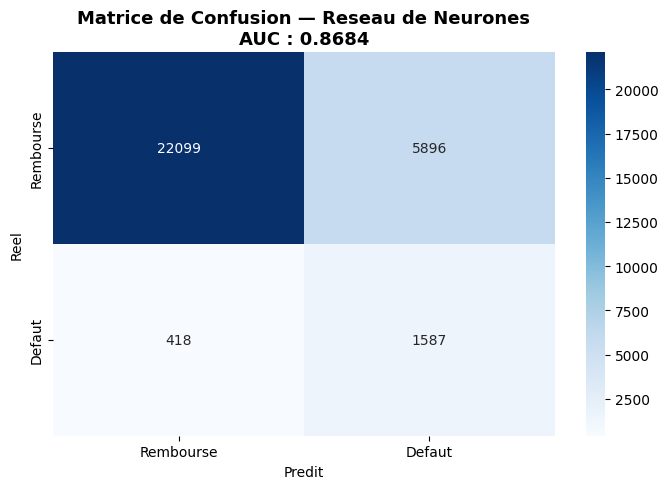

Graphique sauvegarde !


In [18]:
# Evaluation sur le test
print("Evaluation du meilleur modele...")

y_pred_proba = modele.predict(X_test).flatten()
y_pred       = (y_pred_proba > 0.5).astype(int)
auc          = roc_auc_score(y_test, y_pred_proba)

print(f"\nResultats du Reseau de Neurones :")
print(f"AUC-ROC : {auc:.4f}")
print(f"\nRapport de classification :")
print(classification_report(
    y_test, y_pred,
    target_names=['Rembourse', 'Defaut']
))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues', ax=ax,
    xticklabels=['Rembourse', 'Defaut'],
    yticklabels=['Rembourse', 'Defaut']
)
ax.set_title(
    f'Matrice de Confusion — Reseau de Neurones\nAUC : {auc:.4f}',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Reel')
ax.set_xlabel('Predit')
plt.tight_layout()
plt.savefig(
    '../reports/07_confusion_matrix_dl.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")

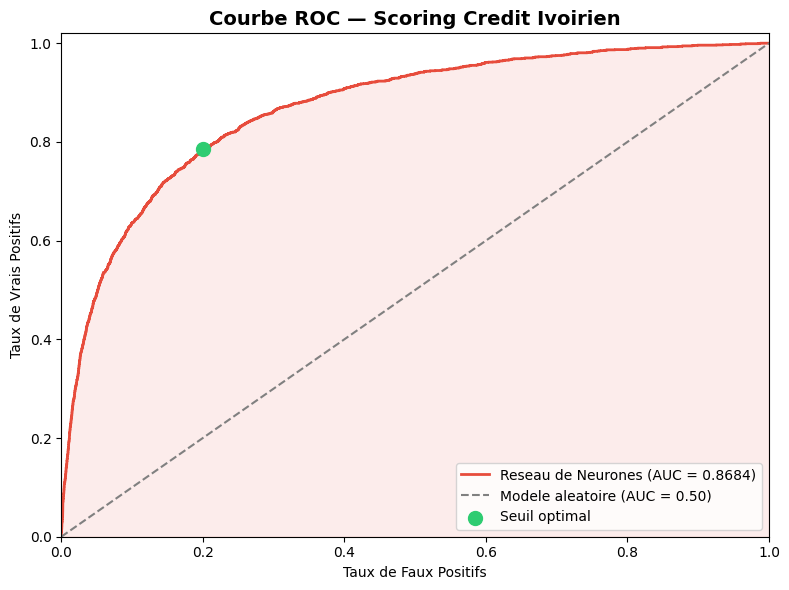

Seuil optimal detecte !
FPR : 0.200
TPR : 0.785


In [19]:
# Courbe ROC
fig, ax = plt.subplots(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

ax.plot(
    fpr, tpr,
    color='#e74c3c', linewidth=2,
    label=f'Reseau de Neurones (AUC = {auc:.4f})'
)
ax.plot(
    [0, 1], [0, 1],
    color='gray', linestyle='--',
    linewidth=1.5, label='Modele aleatoire (AUC = 0.50)'
)

ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

ax.set_title(
    'Courbe ROC — Scoring Credit Ivoirien',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Annotation du point optimal
optimal_idx = np.argmax(tpr - fpr)
ax.scatter(
    fpr[optimal_idx], tpr[optimal_idx],
    color='#2ecc71', s=100, zorder=5,
    label=f'Seuil optimal'
)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(
    '../reports/08_courbe_roc_dl.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print(f"Seuil optimal detecte !")
print(f"FPR : {fpr[optimal_idx]:.3f}")
print(f"TPR : {tpr[optimal_idx]:.3f}")

In [20]:
# Analyse de differents seuils de decision
seuils     = [0.3, 0.4, 0.5, 0.6, 0.7]
resultats  = []

for seuil in seuils:
    y_pred_seuil = (y_pred_proba > seuil).astype(int)
    vp = ((y_pred_seuil == 1) & (y_test == 1)).sum()
    fp = ((y_pred_seuil == 1) & (y_test == 0)).sum()
    fn = ((y_pred_seuil == 0) & (y_test == 1)).sum()

    recall    = vp / (vp + fn) if (vp + fn) > 0 else 0
    precision = vp / (vp + fp) if (vp + fp) > 0 else 0

    resultats.append({
        'Seuil'           : seuil,
        'Defauts detectes': vp,
        'Defauts rates'   : fn,
        'Clients bloques' : fp,
        'Recall (%)'      : f"{recall*100:.1f}%",
        'Precision (%)'   : f"{precision*100:.1f}%"
    })

df_seuils = pd.DataFrame(resultats)
print("Analyse des seuils de decision :\n")
print(df_seuils.to_string(index=False))

Analyse des seuils de decision :

 Seuil  Defauts detectes  Defauts rates  Clients bloques Recall (%) Precision (%)
   0.3              1803            202            10561      89.9%         14.6%
   0.4              1713            292             7991      85.4%         17.7%
   0.5              1587            418             5896      79.2%         21.2%
   0.6              1422            583             3932      70.9%         26.6%
   0.7              1195            810             2328      59.6%         33.9%


In [21]:
# Comparaison ML classique vs Deep Learning
# On va entrainer rapidement XGBoost pour comparer

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

print("Entrainement des modeles baseline...")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr    = lr.predict(X_test)
y_proba_lr   = lr.predict_proba(X_test)[:, 1]
auc_lr       = roc_auc_score(y_test, y_proba_lr)

# XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    scale_pos_weight=n_normal/n_defaut
)
xgb.fit(X_train, y_train)
y_pred_xgb   = xgb.predict(X_test)
y_proba_xgb  = xgb.predict_proba(X_test)[:, 1]
auc_xgb      = roc_auc_score(y_test, y_proba_xgb)

print(f"Logistic Regression AUC : {auc_lr:.4f}")
print(f"XGBoost AUC             : {auc_xgb:.4f}")
print(f"Reseau de Neurones AUC  : {auc:.4f}")

Entrainement des modeles baseline...
Logistic Regression AUC : 0.8471
XGBoost AUC             : 0.8664
Reseau de Neurones AUC  : 0.8684


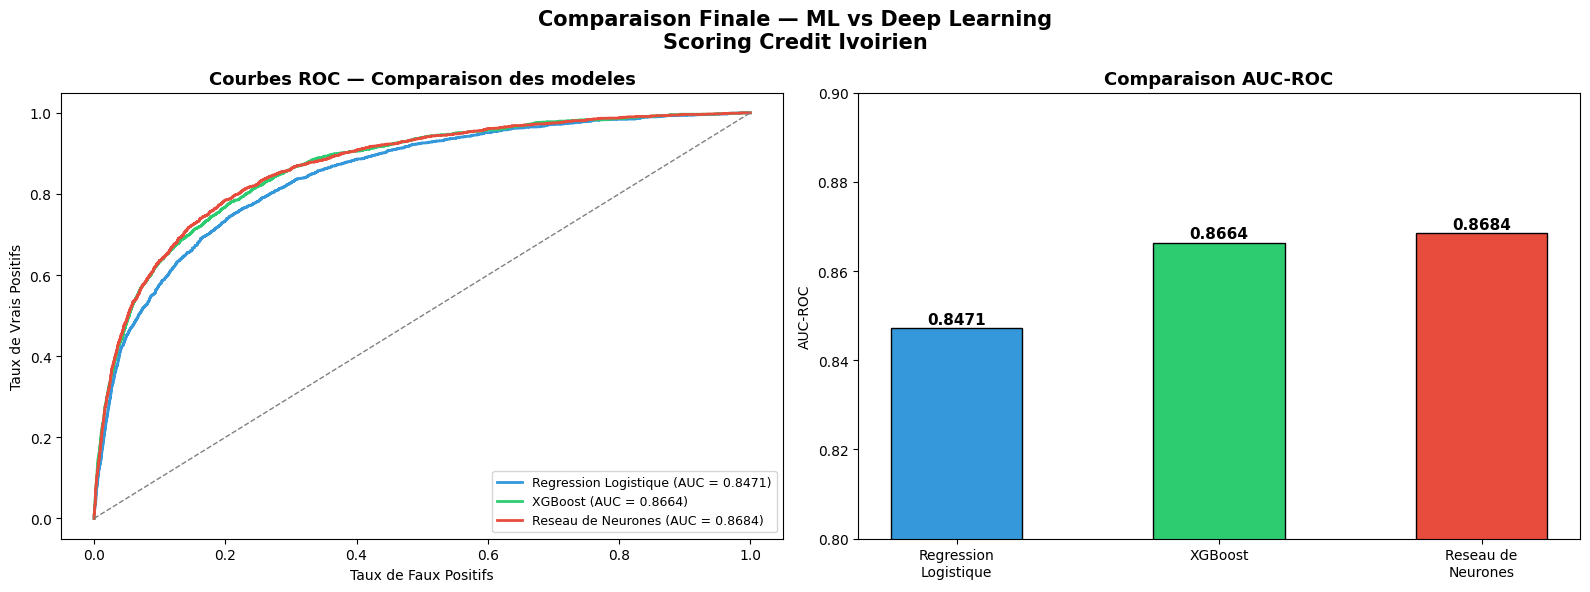

Graphique sauvegarde !


In [22]:
# Graphique comparatif final
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Courbes ROC
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_dl,  tpr_dl,  _ = roc_curve(y_test, y_pred_proba)

axes[0].plot(
    fpr_lr, tpr_lr,
    color='#3498db', linewidth=2,
    label=f'Regression Logistique (AUC = {auc_lr:.4f})'
)
axes[0].plot(
    fpr_xgb, tpr_xgb,
    color='#2ecc71', linewidth=2,
    label=f'XGBoost (AUC = {auc_xgb:.4f})'
)
axes[0].plot(
    fpr_dl, tpr_dl,
    color='#e74c3c', linewidth=2,
    label=f'Reseau de Neurones (AUC = {auc:.4f})'
)
axes[0].plot(
    [0, 1], [0, 1],
    color='gray', linestyle='--', linewidth=1
)
axes[0].set_title(
    'Courbes ROC — Comparaison des modeles',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].legend(loc='lower right', fontsize=9)

# Barres AUC
modeles = [
    'Regression\nLogistique',
    'XGBoost',
    'Reseau de\nNeurones'
]
aucs    = [auc_lr, auc_xgb, auc]
couleurs = ['#3498db', '#2ecc71', '#e74c3c']

bars = axes[1].bar(
    modeles, aucs,
    color=couleurs,
    edgecolor='black',
    width=0.5
)
axes[1].set_title(
    'Comparaison AUC-ROC',
    fontsize=13, fontweight='bold'
)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0.80, 0.90)

for bar, val in zip(bars, aucs):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{val:.4f}',
        ha='center', fontweight='bold',
        fontsize=11
    )

axes[1].axhline(
    y=0.50, color='gray',
    linestyle='--', linewidth=1,
    label='Modele aleatoire'
)

plt.suptitle(
    'Comparaison Finale — ML vs Deep Learning\nScoring Credit Ivoirien',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../reports/09_comparaison_finale.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")